# Notebook 7: Build Your Own Transformer (mini-GPT)
**UCU Deep Learning Course**

In Notebook 6, we left dense networks behind for **images** and saw how convolutions, residual connections, and pretrained backbones bake the right inductive bias into vision models. In this notebook we step into the other modality that drives modern deep learning: **sequences**.

We will build a small **decoder-only transformer** (a "mini-GPT") **from scratch** — no `nn.MultiheadAttention`, no `nn.Transformer*` — and train it character by character on **Tiny Shakespeare**. By the end of the lab the model will generate text that *looks* like Shakespeare (even if it does not quite make sense), and you will be able to peek inside its attention layers to see what each head has learned.

### What you'll learn

1. Implement **scaled dot-product attention** from primitive `torch` ops.
2. Build **causal multi-head self-attention** from scratch (Q/K/V projections, head reshape, causal mask).
3. Assemble a **transformer block** (pre-LN) and stack them into a small GPT.
4. Train the model with a plain PyTorch loop and **generate text** autoregressively (temperature + top-k).
5. **Visualize per-head attention** matrices and interpret the patterns each head learns.
6. *(Optional)* Re-express attention with `torch.einsum`, and refactor the training loop into a **PyTorch Lightning** module.

### References

| Topic | Link |
|-------|------|
| Lecture 8 notes | `../../lectures/lecture 8/notes.md` |
| *Attention Is All You Need* (Vaswani et al., 2017) | https://arxiv.org/abs/1706.03762 |
| Karpathy's nanoGPT | https://github.com/karpathy/nanoGPT |
| PyTorch — building blocks | https://docs.pytorch.org/docs/stable/nn.html |
| PyTorch Lightning | https://lightning.ai/docs/pytorch/stable/ |
| Tiny Shakespeare | https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt |

> **Heads-up.** This notebook trains a model end-to-end. A GPU (CUDA) or Apple MPS device makes the lab comfortable (~3–5 min training). CPU will still work but is noticeably slower — adjust `max_iters` down if you are on CPU.


---

## Part 0 — Setup

Imports, seeds, and device selection. We follow the same `cuda → mps → cpu` pattern from Notebook 6.


In [12]:
# Colab-friendly install (skipped if already available)
try:
    import torchinfo  # noqa: F401
except ImportError:
    %pip install -q torchinfo
try:
    import tiktoken  # noqa: F401
except ImportError:
    %pip install -q tiktoken


In [13]:
from __future__ import annotations

import math
import os
import urllib.request
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary

warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

# UCU color palette (used in plots)
C1, C2, C3 = "#19326E", "#50ACB0", "#CD742A"
C4, C5, C6, C7 = "#A3477F", "#907FAB", "#4294CC", "#89A943"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    print("WARNING: training on CPU will be slow. Consider lowering max_iters below.")

print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cuda
PyTorch version: 2.11.0+cu128


---

## Part 1 — From raw text to model input (~15 min)

This is the **first notebook in the series** that works with text. Before we touch the transformer, we have to answer a basic question: *what does a neural network actually see when its input is text?* Networks operate on tensors of numbers, not strings, so every text pipeline has the same two-step prelude:

```
raw text  --tokenizer-->  integer ids  --embedding-->  dense vectors  -->  transformer
```

### 1. Tokenization — strings ➜ integers

A **tokenizer** is a bookkeeping function that maps a string to a list of integer ids drawn from a fixed **vocabulary** $\mathcal{V}$. Three families are standard:

| Strategy | Vocab size | Pros | Cons |
|----------|-----------|------|------|
| **Word-level** | ~100k–1M | one id per word; meaning aligns with token boundary | enormous vocab; out-of-vocabulary (OOV) words; *walk / walks / walking* unrelated |
| **Character-level** | ~30–200 | tiny vocab; no OOV; trivial to implement | every word has to be re-assembled from characters; longer sequences |
| **Sub-word** (BPE, WordPiece, SentencePiece) | 30k–50k | compromise; frequent words intact, rare words decompose into pieces | tokenizer is itself trained on a corpus; sub-word boundaries are an artefact |

Modern industrial models (BERT, GPT-3/4, Claude, LLaMA) all use **sub-word** tokenizers, typically Byte-Pair Encoding (BPE). For this lab we will use **the GPT-2 BPE tokenizer** — the same pretrained sub-word tokenizer OpenAI shipped with GPT-2 in 2019, and the one that has been re-used (with variants) in countless downstream projects. We load it from the lightweight `tiktoken` library: it ships only the pre-computed merge rules and vocabulary (~1 MB total), no neural-network weights, no internet round-trip needed.

> **A note on data vs vocabulary.** Tiny Shakespeare contains only ~1 MB of text — ~300k BPE tokens. The GPT-2 vocabulary has ~50k entries. That ratio is far worse than what real GPT-2 was trained on (40 GB / ~8 billion tokens). Many rare tokens in the vocab will barely appear in our corpus, which limits what our mini-GPT can learn about them. Use this notebook to learn the **mechanics** of tokenization + transformer training; do not expect generations to rival ChatGPT.

### 2. Embeddings — integers ➜ dense vectors

A character id like `13` is *categorical*: ids `13` and `14` are no closer than `13` and `42`. To turn ids into something a network can compute with, the first layer of any text model is an **embedding table** — a learnable `(vocab_size, d_model)` matrix where each row is a vector for one token. Looking up the embedding for id $i$ is just **row $i$** of the table. This is what `nn.Embedding(vocab_size, d_model)` does.

The table is initialized randomly and **trained end-to-end** with everything else: gradient descent moves the row for each character so that characters appearing in similar contexts end up with similar vectors. By the end of training, the embedding space is the input geometry the transformer has learned to operate on.

### 3. Special tokens (FYI)

You will see special tokens like `[CLS]`, `[SEP]`, `[PAD]`, `[MASK]` in NLP papers. They are ordinary entries in $\mathcal{V}$ reserved for a specific role:

- `[CLS]` — prepended by **encoder** models like BERT. Its final-layer embedding becomes the input's "summary" representation used for classification. (Decoder models like GPT do not need it — they predict at *every* position.)
- `[SEP]` — separates two segments fed jointly (e.g. question + passage in QA).
- `[PAD]` — fills shorter sequences in a batch to a common length; attention is masked out at pad positions.
- `[MASK]` — the token BERT replaces ~15% of inputs with during *masked language modelling* pre-training.

The GPT-2 tokenizer we use has one special token: **`<|endoftext|>`** (id `50256`), which marks document boundaries in the training data. We will not need any of these in this notebook — Tiny Shakespeare is one continuous stream — but you will meet them constantly in real code.

### Tiny Shakespeare

Our dataset is **Tiny Shakespeare**: a single ~1 MB plain-text file with ~40k lines from Shakespeare's plays — the canonical micro-dataset for character-level language models (Karpathy's `char-rnn` / `nanoGPT`). Small enough to train on in minutes, large enough to produce convincingly Shakespearean nonsense.


In [14]:
# Download Tiny Shakespeare (only once)
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = Path("tinyshakespeare.txt")

if not DATA_PATH.exists():
    print("Downloading Tiny Shakespeare...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f"Saved {DATA_PATH} ({DATA_PATH.stat().st_size / 1024:.1f} KB)")

text = DATA_PATH.read_text(encoding="utf-8")
print(f"Corpus length: {len(text):,} characters")
print("First 250 chars:\n" + "-" * 40)
print(text[:250])


Corpus length: 1,115,394 characters
First 250 chars:
----------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



So far we have a plain Python string. The model cannot consume strings — only tensors of integers and floats. The next step is the **tokenizer**.

### Loading the GPT-2 tokenizer with `tiktoken`

`tiktoken.get_encoding("gpt2")` returns the pretrained GPT-2 byte-pair encoder. Two methods are all we will need:

- `tok.encode(s: str) -> list[int]` — string ➜ list of token ids.
- `tok.decode(ids: list[int]) -> str` — token ids ➜ string.

It also exposes `tok.n_vocab` for the vocabulary size.


In [15]:
tok = tiktoken.get_encoding("gpt2")
vocab_size: int = tok.n_vocab

def encode(s: str) -> list[int]:
    return tok.encode(s)

def decode(ids: list[int]) -> str:
    return tok.decode(ids)

# --- quick round-trip check ---
sample = "Hello, world!"
assert decode(encode(sample)) == sample
print(f"vocab_size  = {vocab_size:,}")
print(f"encode('{sample}')  -> {encode(sample)}")
print(f"decode(encode('{sample}')) -> '{decode(encode(sample))}'")


vocab_size  = 50,257
encode('Hello, world!')  -> [15496, 11, 995, 0]
decode(encode('Hello, world!')) -> 'Hello, world!'


### Exercise 1.1 — Inspect the tokenizer

This is mostly a **read-along** exercise — there is no implementation to fill in (the tokenizer is pretrained!). Run the cell below and look carefully at the breakdown. Notice three things:

1. The number of tokens is **far smaller** than the number of characters — BPE compresses common letter sequences into single tokens. The ratio is ~3–4× for English.
2. Tokens are **sub-words, not words**. Frequent words like `"Romeo"` may be a single token; rare or capitalized words split into pieces.
3. **Leading spaces matter** — `" the"` and `"the"` are typically different tokens. This is a GPT-2 quirk: the tokenizer encodes the space *as part of* the following word.

Try changing `sample` to your own sentence and re-run.


In [16]:
sample = "ROMEO: O, she doth teach the torches to burn bright!"
ids = encode(sample)
print(f"original  ({len(sample)} chars):  {sample!r}")
print(f"token ids ({len(ids)} tokens):   {ids}")
print(f"compression: {len(sample) / len(ids):.2f} chars / token\n")
print("piece-by-piece breakdown:")
for i in ids:
    piece = tok.decode([i])
    print(f"  {i:>6}  {piece!r}")


original  (52 chars):  'ROMEO: O, she doth teach the torches to burn bright!'
token ids (15 tokens):   [33676, 4720, 25, 440, 11, 673, 288, 849, 4545, 262, 49497, 284, 4245, 6016, 0]
compression: 3.47 chars / token

piece-by-piece breakdown:
   33676  'ROM'
    4720  'EO'
      25  ':'
     440  ' O'
      11  ','
     673  ' she'
     288  ' d'
     849  'oth'
    4545  ' teach'
     262  ' the'
   49497  ' torches'
     284  ' to'
    4245  ' burn'
    6016  ' bright'
       0  '!'


> **Question 1.1** — Look at your breakdown. Find at least one example of each of the following in the same sentence:
>
> (a) A whole common word that becomes a **single token**.
>
> (b) A word that is **split** into two or more sub-word pieces.
>
> (c) A token that includes a **leading space** as part of its surface form.
>
> Why is sub-word tokenization a better trade-off than word-level (which would have ~500k vocab entries) or character-level (~100 vocab entries) for general-purpose text models?


- **(a) Un solo token:** `" teach"` (4545), `" the"` (262), `" to"` (284), `" burn"` (4245), `" bright"` (6016) son cada una un único token; las palabras frecuentes permanecen intactas.
- **(b) Palabra dividida en subpalabras:** `"ROM"` + `"EO"`, y `" d"` + `"oth"`. Las palabras más raras o poco comunes se fragmentan en partes.
- **(c) Token con un espacio inicial:** `" she"`, `" O"`, `" the"`, `" teach"`, ... el BPE de GPT-2 une el espacio precedente a la palabra, por lo que `" the"` y `"the"` tienen identificadores diferentes.

**Por qué las subpalabras son el mejor compromiso.** Se sitúan entre dos extremos:

- *frente al nivel de palabra (~500k de vocabulario):* un vocabulario enorme hace que la tabla de embeddings y la capa softmax final sean gigantescas y lentas, y aun así falla con palabras **fuera de vocabulario (OOV)**; las variantes morfológicas (`walk`/`walks`/`walking`) reciben identificadores no relacionados. BPE mantiene el vocabulario acotado (~50k) y, al poder retroceder finalmente hasta bytes sin procesar, **no tiene OOV**: cualquier cadena puede codificarse.
- *frente al nivel de carácter (~100 de vocabulario):* los caracteres aportan muy poco significado y multiplican la **longitud de la secuencia** (~3,3x más tokens en este caso), por lo que el modelo desperdicia capacidad y atención simplemente reconstruyendo palabras, y las dependencias de largo alcance se vuelven más difíciles.

La tokenización por subpalabras mantiene las palabras frecuentes como tokens únicos y significativos (secuencias cortas), mientras que sigue descomponiendo las palabras raras de forma adecuada: el punto óptimo entre tamaño del vocabulario, longitud de secuencia y capacidad de generalización.


### From ids to vectors: the embedding lookup

The tokenizer's output is integers — but the transformer expects vectors. The bridge is an **embedding layer**: a learnable `(vocab_size, d_model)` matrix where the $i$-th row is the embedding of token $i$. `nn.Embedding` is just this lookup.

Let's instantiate a tiny embedding table (`d_model = 8` so each row fits on screen) and embed the tokens of `"the the"`. The embedding values are random right now — *they would be learned during training*.


In [17]:
# Tiny demo embedding — d_model=8 so each row fits on screen
torch.manual_seed(0)
demo_emb = nn.Embedding(vocab_size, 8)
sample_ids = torch.tensor(encode("the the"))
print(f"input string : 'the the'")
print(f"token ids    : {sample_ids.tolist()}    shape: {tuple(sample_ids.shape)}")
print("decoded pieces:", [tok.decode([i.item()]) for i in sample_ids])
print(f"\nafter nn.Embedding(vocab_size, 8):")
print(demo_emb(sample_ids))
print(f"output shape : {tuple(demo_emb(sample_ids).shape)}    (T, d_model)")


input string : 'the the'
token ids    : [1169, 262]    shape: (2,)
decoded pieces: ['the', ' the']

after nn.Embedding(vocab_size, 8):
tensor([[-1.4872, -0.1879, -0.0690, -0.8529, -0.0059,  0.2179, -0.0597, -0.2301],
        [ 0.8183,  1.2512, -0.4571, -1.0858,  0.0431,  0.4952, -0.9355, -0.6429]],
       grad_fn=<EmbeddingBackward0>)
output shape : (2, 8)    (T, d_model)


Three things to notice:

1. The output shape is `(T, d_model)` — a 2-D tensor of `T` vectors, ready to be processed by the transformer.
2. Repeated tokens (the two occurrences of `" the"`) produce **the same vector**. The embedding only knows about the token identity, not its position. That is why we will need a **positional encoding** in Part 3 — without it, the transformer would treat shuffled sequences as identical.
3. The first `"the"` (no leading space, id `the` from start-of-text) and the second `" the"` (with leading space) are **different tokens** — that is why the two rows above are not all identical.

In our full model `d_model = 128`. The embedding table has $\text{vocab\_size} \times 128 \approx 6.4$ million parameters — by far the largest single component of the model. We will share this table with the output projection later (a trick called **weight tying**) to avoid duplicating it.


### Splitting the corpus

Now encode the **entire corpus** to a single `torch.long` tensor of shape `(len(text),)`, and split it 90/10 into `train_data` and `val_data` — **contiguously**, by taking the first 90% of tokens for training and the last 10% for validation.


In [18]:
data = torch.tensor(encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data = data[n_train:]
print(f"corpus      : {len(text):,} characters  =>  {len(data):,} tokens")
print(f"compression : {len(text) / len(data):.2f} chars / token")
print(f"train tokens: {len(train_data):,}    val tokens: {len(val_data):,}")


corpus      : 1,115,394 characters  =>  338,025 tokens
compression : 3.30 chars / token
train tokens: 304,222    val tokens: 33,803


> **Question 1.2** — Why do we split *contiguously* (first 90% / last 10%) rather than randomly shuffling token indices? What would go wrong if we shuffled?


Hay dos razones, ambas relacionadas con **no filtrar información del futuro hacia el pasado**:

1. **Un modelo de lenguaje necesita secuencias contiguas.** Cada ejemplo de entrenamiento es una ventana `tokens[i : i+block_size]` con objetivos desplazados una posición. Ese objetivo solo tiene sentido si los tokens vecinos permanecen adyacentes; mezclar aleatoriamente los *índices* de los tokens desordenaría la secuencia y destruiría precisamente la estructura (contexto al siguiente token) que queremos aprender.
2. **Evitar fugas entre entrenamiento y validación.** Si mezcláramos los datos y *luego* los dividiéramos, un token de validación en la posición `i` seguiría teniendo sus vecinos `i−1, i+1, ...` dentro del conjunto de entrenamiento (ya que las ventanas son fragmentos contiguos). El modelo habría entrenado efectivamente con el contexto inmediato de los tokens de validación, por lo que la pérdida de validación estaría sesgada de forma optimista y dejaría de medir la verdadera capacidad de generalización.

Una división **contigua** reserva una región continua del texto (el último 10%) que el modelo nunca ve durante el entrenamiento, proporcionando una estimación honesta de qué tan bien modela texto *no visto* de Shakespeare.


### Exercise 1.2 — `TokenDataset`

Build a `Dataset` that yields fixed-length windows over the token stream. Each item is a pair `(x, y)` with:

- `x` of shape `(block_size,)` containing `tokens[i : i + block_size]`.
- `y` of shape `(block_size,)` containing `tokens[i + 1 : i + block_size + 1]` (next-token targets at every position).

For a window of length `block_size` we have `block_size` training signals per example (one per position) — language models are *dense* supervision.


In [35]:
class TokenDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        # Valid start indices are 0 .. len(data) - block_size - 1, because the
        # target window y reaches one position further than x.
        return len(self.data) - self.block_size

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.data[idx : idx + self.block_size]              # context
        y = self.data[idx + 1 : idx + self.block_size + 1]      # next-token targets (x shifted by 1)
        return x, y


BLOCK_SIZE = 128
BATCH_SIZE = 64

train_dataset = TokenDataset(train_data, BLOCK_SIZE)
val_dataset = TokenDataset(val_data, BLOCK_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

# --- verification ---
xb, yb = next(iter(train_loader))
assert xb.shape == (BATCH_SIZE, BLOCK_SIZE), f"expected (64, 128), got {xb.shape}"
assert yb.shape == (BATCH_SIZE, BLOCK_SIZE)
assert (yb[:, :-1] == xb[:, 1:]).all(), "y must be x shifted by 1"
print(f"x batch shape: {xb.shape}    y batch shape: {yb.shape}")
print(f"first window:\n  x = '{decode(xb[0, :40].tolist())}'\n  y = '{decode(yb[0, :40].tolist())}'")

x batch shape: torch.Size([64, 128])    y batch shape: torch.Size([64, 128])
first window:
  x = ' and brothers haught and proud:
And were they to be ruled, and not to rule,
This sickly land might solace as before.

First Citizen:
Come, come'
  y = ' brothers haught and proud:
And were they to be ruled, and not to rule,
This sickly land might solace as before.

First Citizen:
Come, come,'


### What is a "language model", exactly?

The pair `(x, y)` we just built — where `y` is `x` shifted by one — *is* the autoregressive language-modelling objective:

> Given the previous tokens, predict the next one.

A window of length `block_size` gives us `block_size` separate (context, next-token) training examples in a single forward pass. Language models are densely supervised — every position contributes a gradient — and that is a big part of why they scale so well.

Let's make this concrete with the first few token positions of a real training window. Notice that with BPE the "next token" is a sub-word, not a character.


In [20]:
xb, yb = next(iter(train_loader))
ctx = xb[0]   # one window, shape (block_size,)
tgt = yb[0]

print(f"{'pos':>3}  {'context so far':<60}  {'->':2}  {'predict':>12}")
print("-" * 86)
for t in range(8):
    context_str = decode(ctx[:t + 1].tolist()).replace("\n", "\\n")
    target_str = decode([tgt[t].item()]).replace("\n", "\\n")
    print(f"{t:>3}  {context_str!r:<60}  ->  {target_str!r:>12}")


pos  context so far                                                ->       predict
--------------------------------------------------------------------------------------
  0  ' promise'                                                    ->       ' them'
  1  ' promise them'                                               ->    ' success'
  2  ' promise them success'                                       ->        ' and'
  3  ' promise them success and'                                   ->    ' victory'
  4  ' promise them success and victory'                           ->           '.'
  5  ' promise them success and victory.'                          ->         '\\n'
  6  ' promise them success and victory.\\n'                       ->       'Blood'
  7  ' promise them success and victory.\\nBlood'                  ->           'y'


Two ideas worth naming:

- **Teacher forcing.** During training, the input at position $n$ is always the *true* preceding context — never the model's own past predictions. This lets every position in the window contribute a gradient *simultaneously* (parallel training). At inference time we drop teacher forcing and feed back what the model itself sampled — that is what makes generation autoregressive.

- **Causal / autoregressive constraint.** Position $n$ may only depend on positions $\le n$. If the model could peek at the future, it would learn to copy `y` from `x` and the objective would be trivial. This constraint is the *only* architectural difference between **GPT-style decoders** (which we are building) and **BERT-style encoders** (which see the whole sequence bidirectionally and are trained on a different objective — masked-token prediction). Same transformer blocks, same MLPs, same LayerNorms — the decoder just adds a **causal mask** to the attention scores.

That mask is the next thing we will build.


---

## Part 2 — Self-attention from scratch (~25 min)

This is the core of the lecture. Given an input sequence of token embeddings $\mathbf{X}\in\mathbb{R}^{B\times T\times D}$, self-attention produces an output of the same shape where each token has been updated with a content-dependent mixture of the other tokens.

The recipe (from lecture §2):

1. Project the input to three matrices: **queries** $\mathbf{Q}$, **keys** $\mathbf{K}$, **values** $\mathbf{V}$, all of shape $(B, T, D)$.
2. Reshape into $H$ heads of dimension $D_h = D/H$: $(B, H, T, D_h)$.
3. Compute scaled dot-product attention per head:
$$
\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{D_h}} + \text{mask}\right)\mathbf{V}
$$
4. Concatenate heads and project with a final output linear layer.

For a **decoder** (GPT-style), position $t$ may only attend to positions $\le t$ — we enforce this with a **causal mask** that fills the upper triangle of the attention scores with $-\infty$ before the softmax.


### Exercise 2.1 — Scaled dot-product attention

Implement the core attention function. It takes:

- `q, k, v` of shape `(B, H, T, D_h)`
- `mask` of shape `(T, T)` (or `None`) — a boolean tensor where `True` means **block this position** (i.e. set the score to $-\infty$).

Return `(out, attn)` where `out` has shape `(B, H, T, D_h)` and `attn` has shape `(B, H, T, T)` (we will use `attn` later for visualization).

Hint: `torch.matmul(q, k.transpose(-2, -1))` gives scores; `.masked_fill(mask, float('-inf'))` then `F.softmax(..., dim=-1)`.


In [21]:
def scaled_dot_product_attention(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    # Returns (output, attention_weights).
    # Shapes: q,k,v: (B, H, T, D_h); mask: (T, T) bool, True=block.
    # output: (B, H, T, D_h); attn: (B, H, T, T)
    d_h = q.size(-1)
    # 1. Similarity of every query to every key.        (B, H, T, T)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_h)
    # 2. Causal mask: blocked (future) positions -> -inf so softmax kills them.
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    # 3. Softmax over the KEY axis -> each query row sums to 1.
    attn = F.softmax(scores, dim=-1)
    # 4. Weighted average of the values.                 (B, H, T, D_h)
    out = torch.matmul(attn, v)
    return out, attn


# --- sanity check ---
B, H, T, Dh = 2, 4, 8, 16
q = torch.randn(B, H, T, Dh)
k = torch.randn(B, H, T, Dh)
v = torch.randn(B, H, T, Dh)
mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)  # causal

out, attn = scaled_dot_product_attention(q, k, v, mask)
assert out.shape == (B, H, T, Dh)
assert attn.shape == (B, H, T, T)
assert torch.allclose(attn.sum(dim=-1), torch.ones(B, H, T), atol=1e-5), "rows must sum to 1"
# causal property: position 0 attends only to position 0
assert torch.allclose(attn[:, :, 0, 1:], torch.zeros(B, H, T - 1), atol=1e-7)
print("scaled_dot_product_attention OK")
print(f"output shape: {out.shape}   attn shape: {attn.shape}")

scaled_dot_product_attention OK
output shape: torch.Size([2, 4, 8, 16])   attn shape: torch.Size([2, 4, 8, 8])


> **Question 2.1** — Why do we divide the dot products by $\sqrt{D_h}$? What happens (a) without the scaling, when $D_h$ is large, and (b) to the **gradients** that flow back through softmax in that regime?


Una puntuación es un producto escalar sobre `D_h` dimensiones: $q\cdot k=\sum_{d=1}^{D_h} q_d k_d$. Si las entradas son aproximadamente independientes, con media cero y varianza unitaria, esta suma tiene media 0 y **varianza $D_h$**, es decir, una magnitud típica de $\sqrt{D_h}$. Por lo tanto, las puntuaciones sin escalar crecen con la dimensión de la cabeza de atención; dividir por $\sqrt{D_h}$ las reescala de nuevo a **varianza unitaria**, independientemente de $D_h$.

**(a) Sin escalado y con un $D_h$ grande:** los logits que entran en la softmax adquieren magnitudes elevadas. La softmax aplicada a logits grandes **se satura**: casi toda la masa de probabilidad colapsa sobre la puntuación más alta, de modo que la atención degenera en un `argmax` casi rígido y deja de combinar suavemente información entre distintas posiciones.

**(b) Gradientes:** en ese régimen saturado, el jacobiano de la softmax $\partial p_i/\partial z_j = p_i(\delta_{ij}-p_j)$ es aproximadamente 0 (un $p_i\approx 1$ y el resto $\approx 0$). Los gradientes que atraviesan los pesos de atención **se desvanecen**, por lo que las proyecciones Q/K apenas reciben señal de aprendizaje y el entrenamiento se estanca. El factor $1/\sqrt{D_h}$ mantiene los logits en el orden de $O(1)$ y la softmax en una región bien condicionada con gradientes saludables.


### Exercise 2.2 — Causal multi-head self-attention

Implement `CausalSelfAttention` as a `nn.Module`. The forward pass should:

1. Take `x` of shape `(B, T, D)`.
2. Project to Q, K, V using a **single** `nn.Linear(d_model, 3 * d_model)` (more efficient than three separate linears).
3. Reshape to `(B, n_heads, T, head_dim)` where `head_dim = d_model // n_heads`.
4. Apply scaled dot-product attention with a causal mask sliced from a `(block_size, block_size)` registered buffer.
5. Reshape back to `(B, T, D)` and project through an output `nn.Linear(d_model, d_model)` + dropout.

The forward signature supports `return_attn: bool = False`. When `True`, also return the attention weights `(B, n_heads, T, T)`. We will use this in Part 5 for visualization.

Why a registered buffer? `register_buffer('tril', ...)` makes the causal mask a non-trainable tensor that moves with `model.to(device)` automatically — no manual device handling.


In [22]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, block_size: int, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.d_model = d_model

        # One fused linear produces Q, K and V in a single matmul.
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # Causal mask as a non-trainable buffer (True = block this future position).
        # Registered so it follows model.to(device) automatically.
        self.register_buffer(
            "tril",
            torch.triu(torch.ones(block_size, block_size, dtype=torch.bool), diagonal=1),
        )

    def forward(
        self, x: torch.Tensor, return_attn: bool = False
    ) -> torch.Tensor | tuple[torch.Tensor, torch.Tensor]:
        B, T, D = x.shape
        # 1. Project to q, k, v -> each (B, T, D).
        q, k, v = self.qkv_proj(x).split(self.d_model, dim=-1)
        # 2. Split the channels into heads: (B, T, D) -> (B, n_heads, T, head_dim).
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        # 3. Causal mask sliced to the current length T.
        mask = self.tril[:T, :T]
        # 4. Scaled dot-product attention (per head, in parallel).
        out, attn = scaled_dot_product_attention(q, k, v, mask)
        out = self.attn_dropout(out)
        # 5. Merge heads back and project: (B, n_heads, T, head_dim) -> (B, T, D).
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        out = self.resid_dropout(self.out_proj(out))
        if return_attn:
            return out, attn
        return out


# --- sanity check ---
d_model, n_heads = 128, 4
attn = CausalSelfAttention(d_model, n_heads, block_size=BLOCK_SIZE)
x = torch.randn(2, 16, d_model)
y = attn(x)
assert y.shape == x.shape
y2, a = attn(x, return_attn=True)
assert a.shape == (2, n_heads, 16, 16)
print(f"CausalSelfAttention output shape: {y.shape}")
print(f"attention weights shape: {a.shape}")
print(f"params: {sum(p.numel() for p in attn.parameters()):,}")

CausalSelfAttention output shape: torch.Size([2, 16, 128])
attention weights shape: torch.Size([2, 4, 16, 16])
params: 66,048


> **Question 2.2** — Why do we slice the mask as `tril[:T, :T]` at every forward pass instead of just using the full `(block_size, block_size)` buffer? When would this matter?


El búfer se asigna una sola vez con el tamaño máximo `(block_size, block_size)`, pero una pasada hacia adelante (*forward pass*) puede recibir una secuencia **más corta** que `block_size`. En ese caso, las puntuaciones de atención tienen forma `(B, H, T, T)`, por lo que la máscara también debe tener forma `(T, T)`; al usar `tril[:T, :T]` se obtiene el subbloque causal correcto de la esquina superior izquierda. El búfer completo tendría una forma incorrecta y no podría difundirse (*broadcast*) correctamente sobre las puntuaciones.

**Cuándo importa:** durante la **generación autorregresiva**, donde el contexto comienza con longitud 1 y crece token a token (cada paso tiene un valor diferente de `T < block_size`), y de manera más general siempre que se utilicen entradas de longitud variable. Durante el entrenamiento con ventanas de longitud fija y completa, `T == block_size`, por lo que el recorte no tiene efecto; sin embargo, la generación fallaría sin él.


---

## Part 3 — Transformer block and mini-GPT (~20 min)

A **transformer block** wraps multi-head self-attention and a per-token MLP inside two residual connections. Modern transformers use a **pre-LN** variant where LayerNorm is applied *before* each sub-block:

$$
\mathbf{x} \leftarrow \mathbf{x} + \text{Attn}(\text{LN}(\mathbf{x})) \qquad
\mathbf{x} \leftarrow \mathbf{x} + \text{MLP}(\text{LN}(\mathbf{x}))
$$

The MLP is a 2-layer feed-forward network with hidden width $4D$ and GELU activation — this is the standard transformer FFN.


### Exercise 3.1 — `TransformerBlock`

Implement the pre-LN transformer block as described above. The MLP is:

`Linear(d_model, 4*d_model) → GELU → Linear(4*d_model, d_model) → Dropout`

The forward also takes `return_attn` and forwards it through the attention sub-module.


In [23]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, block_size: int, dropout: float = 0.1) -> None:
        super().__init__()
        # Pre-LN: LayerNorm is applied BEFORE each sub-block.
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        # Position-wise feed-forward: expand x4, GELU, project back.
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(
        self, x: torch.Tensor, return_attn: bool = False
    ) -> torch.Tensor | tuple[torch.Tensor, torch.Tensor]:
        # Residual around attention (pre-LN).
        if return_attn:
            attn_out, attn = self.attn(self.ln1(x), return_attn=True)
        else:
            attn_out = self.attn(self.ln1(x))
        x = x + attn_out
        # Residual around the MLP (pre-LN).
        x = x + self.mlp(self.ln2(x))
        if return_attn:
            return x, attn
        return x


# --- sanity check ---
block = TransformerBlock(d_model=128, n_heads=4, block_size=BLOCK_SIZE)
x = torch.randn(2, 16, 128)
y = block(x)
assert y.shape == x.shape
y2, a = block(x, return_attn=True)
assert a.shape == (2, 4, 16, 16)
print(f"TransformerBlock OK    params: {sum(p.numel() for p in block.parameters()):,}")

TransformerBlock OK    params: 198,272


> **Question 3.1** — In the lecture notes the transformer is written **post-LN** (LayerNorm *after* each residual sum), but we use **pre-LN** here. What is the practical advantage of pre-LN, especially for deep stacks of blocks?


**Pre-LN mantiene una vía residual limpia.** En Pre-LN, $x \leftarrow x + \text{Sublayer}(\text{LN}(x))$: la conexión residual es una **ruta de identidad intacta** y la normalización por capas (*LayerNorm*) se encuentra *dentro* de la rama residual. Los gradientes fluyen directamente hacia atrás a través de `+ x`, conservando su magnitud, por lo que incluso pilas profundas de capas permanecen numéricamente estables y entrenables, normalmente **sin necesidad de calentamiento de la tasa de aprendizaje (*learning-rate warmup*)**.

En Post-LN, $x \leftarrow \text{LN}(x + \text{Sublayer}(x))$: cada suma residual se vuelve a normalizar, por lo que el gradiente debe atravesar una *LayerNorm* en **cada** capa. En modelos profundos, esto provoca que las magnitudes de los gradientes varíen con la profundidad durante la inicialización, generando inestabilidad que suele requerir un calentamiento cuidadoso y tasas de aprendizaje más pequeñas. Por esta razón, los transformadores profundos modernos (GPT-2, GPT-3, nanoGPT, LLaMA) utilizan **Pre-LN**: permite entrenar modelos más profundos, más rápido y con mayor robustez.


### Exercise 3.2 — `MiniGPT`

Assemble the full model. It needs:

- A token embedding `nn.Embedding(vocab_size, d_model)`.
- A **learned** positional embedding `nn.Embedding(block_size, d_model)`.
- `n_layers` of `TransformerBlock`.
- A final `LayerNorm`.
- A language-modeling head `nn.Linear(d_model, vocab_size, bias=False)`.

**Weight tying.** With `vocab_size ≈ 50k` and `d_model = 128`, the embedding table is 6.4 M parameters and the LM head would *duplicate* that. The standard trick — used in GPT-2 / GPT-3 / nanoGPT / most modern LMs — is to **share the same weights** between the input embedding and the output projection: `self.lm_head.weight = self.tok_emb.weight`. This halves the parameter count and often improves generalization (the two roles are dual: row $i$ of the embedding *is* the direction in which logit $i$ points).

Forward signature: `forward(idx: Tensor, targets: Tensor | None = None) -> (logits, loss | None)`.

- `idx` has shape `(B, T)` — token ids.
- If `targets` is provided, also compute the cross-entropy loss (flatten `(B, T, V)` logits and `(B, T)` targets to `(B*T, V)` and `(B*T,)`). Otherwise, `loss = None`.

This `(logits, loss)` convention is the nanoGPT-style API and makes the training loop a one-liner.


In [24]:
class MiniGPT(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 128,
        n_heads: int = 4,
        n_layers: int = 4,
        block_size: int = 128,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)        # token identity
        self.pos_emb = nn.Embedding(block_size, d_model)        # learned absolute position
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, block_size, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)                       # final LayerNorm
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        # Weight tying: the output projection reuses the input embedding matrix.
        self.lm_head.weight = self.tok_emb.weight
        # GPT-2 style small init: keeps initial logits tiny so the *untrained*
        # cross-entropy starts near ln(vocab_size) (see Question 3.2).
        self.apply(self._init_weights)

    def _init_weights(self, module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(
        self, idx: torch.Tensor, targets: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        B, T = idx.shape
        assert T <= self.block_size, f"sequence length {T} > block_size {self.block_size}"
        # 1. Token + positional embeddings (broadcast pos over the batch).
        pos = torch.arange(T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)               # (B, T, D)
        x = self.drop(x)
        # 2. Stack of transformer blocks.
        for block in self.blocks:
            x = block(x)
        # 3. Final LayerNorm + language-modeling head.
        x = self.ln_f(x)
        logits = self.lm_head(x)                                # (B, T, vocab_size)
        # 4. Cross-entropy loss if targets are provided.
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss


# --- sanity check ---
model = MiniGPT(vocab_size=vocab_size, d_model=128, n_heads=4, n_layers=4, block_size=BLOCK_SIZE).to(device)
idx = torch.randint(0, vocab_size, (2, 16), device=device)
logits, loss = model(idx)
assert logits.shape == (2, 16, vocab_size)
assert loss is None
logits, loss = model(idx, targets=torch.randint(0, vocab_size, (2, 16), device=device))
assert loss.ndim == 0
n_params = sum(p.numel() for p in model.parameters())
n_unique = sum(p.numel() for p in model.parameters() if p.requires_grad) - (model.tok_emb.weight.numel() if model.lm_head.weight is model.tok_emb.weight else 0)
print(f"MiniGPT OK    loss = {loss.item():.4f}    expected ≈ ln(vocab_size) = {math.log(vocab_size):.4f}")
print(f"total params (with tying): {n_params:,}    (without tying would be ~{n_params + model.tok_emb.weight.numel():,})")

summary(model, input_data=idx, col_names=["input_size", "output_size", "num_params"], depth=2)

MiniGPT OK    loss = 10.8991    expected ≈ ln(vocab_size) = 10.8249
total params (with tying): 7,242,624    (without tying would be ~13,675,520)


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
MiniGPT                                       [2, 16]                   [2, 16, 50257]            --
├─Embedding: 1-1                              [2, 16]                   [2, 16, 128]              6,432,896
├─Embedding: 1-2                              [16]                      [16, 128]                 16,384
├─Dropout: 1-3                                [2, 16, 128]              [2, 16, 128]              --
├─ModuleList: 1-4                             --                        --                        --
│    └─TransformerBlock: 2-1                  [2, 16, 128]              [2, 16, 128]              198,272
│    └─TransformerBlock: 2-2                  [2, 16, 128]              [2, 16, 128]              198,272
│    └─TransformerBlock: 2-3                  [2, 16, 128]              [2, 16, 128]              198,272
│    └─TransformerBlock: 2-4                  [2, 16, 128]  

> **Question 3.2** — An untrained model should produce a cross-entropy loss close to $\ln(\text{vocab\_size})$. Why? What is this value for our vocabulary, and what does it represent?


Antes de cualquier entrenamiento, el modelo no ha aprendido nada, por lo que lo mejor que puede hacer para predecir el siguiente token es producir una distribución aproximadamente **uniforme** sobre las `V` entradas del vocabulario: $p_i \approx 1/V$. La entropía cruzada es entonces $-\log p_{\text{verdadero}} = -\log(1/V) = \log V$.

Para nuestro vocabulario, $V = 50{,}257$, esto da $\ln(50257) \approx \mathbf{10.82}$. Es la **entropía de la distribución uniforme** sobre el vocabulario: la pérdida de un modelo que no sabe nada y no tiene ninguna preferencia entre los distintos tokens. Cualquier aprendizaje real reducirá la pérdida por debajo de esta línea base, lo que la convierte en una comprobación útil durante la primera iteración: si la pérdida inicial está muy alejada de $\ln V$, probablemente exista algún problema en la inicialización o en el cálculo de la función de pérdida.


---

## Part 4 — Train the model and generate text (~25 min)

We train with **AdamW** and a constant learning rate. Validation loss is estimated periodically on a few minibatches rather than the entire validation loader (faster, less code).

The training and evaluation helpers below are provided.


In [25]:
@torch.no_grad()
def estimate_loss(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    max_batches: int = 20,
) -> dict[str, float]:
    # Estimate mean train/val loss over a handful of batches each.
    out: dict[str, float] = {}
    model.eval()
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        losses = []
        for i, (xb, yb) in enumerate(loader):
            if i >= max_batches:
                break
            xb, yb = xb.to(device), yb.to(device)
            _, loss = model(xb, targets=yb)
            losses.append(loss.item())
        out[name] = float(np.mean(losses))
    model.train()
    return out


### Exercise 4.1 — Training loop

Pick reasonable hyperparameters and run the training loop. Suggested values:

- `max_iters = 3000` (drop to ~1500 on CPU)
- `eval_interval = 300`
- `learning_rate = 3e-4`

The loop should:

1. Build a `torch.optim.AdamW` optimizer over `model.parameters()` with the chosen `lr`.
2. Iterate `max_iters` times, drawing one batch per iteration from a *cycled* train iterator (so we keep training past one epoch).
3. Forward → loss → `zero_grad` → `backward` → `step`.
4. Every `eval_interval` iterations, call `estimate_loss(...)` and log to a list (`history`).

Plot train and val loss at the end.


In [26]:
# Provided: infinite iterator over a DataLoader
def cycle(loader: DataLoader):
    while True:
        for batch in loader:
            yield batch


iter     0 | train 10.8342 | val 10.8222
iter   300 | train 5.3065 | val 5.0876
iter   600 | train 4.5290 | val 4.4120
iter   900 | train 4.1441 | val 4.1288
iter  1200 | train 3.9190 | val 3.9044
iter  1500 | train 3.6988 | val 3.8116
iter  1800 | train 3.5002 | val 3.7872
iter  2100 | train 3.3452 | val 3.7737
iter  2400 | train 3.1716 | val 3.8212
iter  2700 | train 3.0198 | val 3.8819
iter  3000 | train 2.9043 | val 3.9076


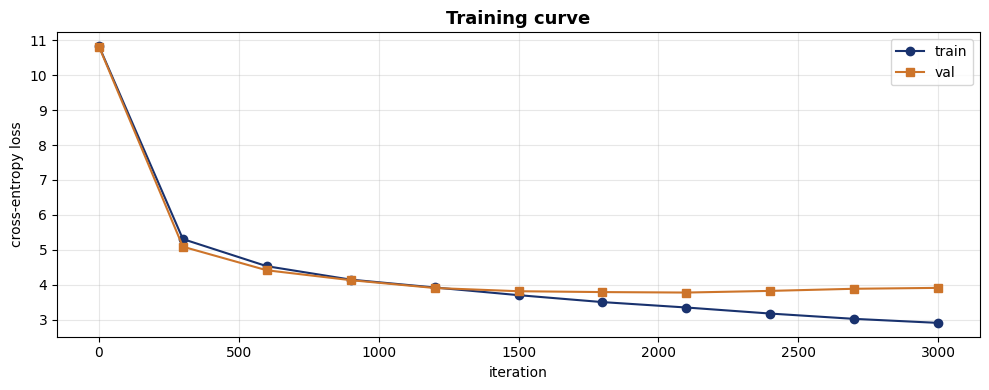

In [27]:
max_iters: int = 3000          # drop to ~1500 if you are on CPU
eval_interval: int = 300
learning_rate: float = 3e-4

# 1. Re-instantiate the model fresh so every re-run starts from scratch.
model = MiniGPT(
    vocab_size=vocab_size,
    d_model=128,
    n_heads=4,
    n_layers=4,
    block_size=BLOCK_SIZE,
    dropout=0.1,
).to(device)

# 2. AdamW over all parameters.
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# 3. Infinite stream of training batches (keeps going past one epoch).
train_iter = cycle(train_loader)

history: list[dict[str, float]] = []
model.train()
for it in range(max_iters + 1):
    # 4. Periodically estimate train/val loss and log it.
    if it % eval_interval == 0:
        stats = estimate_loss(model, train_loader, val_loader)
        stats["iter"] = it
        history.append(stats)
        print(f"iter {it:>5} | train {stats['train']:.4f} | val {stats['val']:.4f}")

    # one optimization step
    xb, yb = next(train_iter)
    xb, yb = xb.to(device), yb.to(device)
    _, loss = model(xb, targets=yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# --- plot ---
iters = [h["iter"] for h in history]
plt.figure(figsize=(10, 4))
plt.plot(iters, [h["train"] for h in history], color=C1, marker="o", label="train")
plt.plot(iters, [h["val"] for h in history], color=C3, marker="s", label="val")
plt.xlabel("iteration"); plt.ylabel("cross-entropy loss"); plt.legend()
plt.grid(True, alpha=0.3); plt.title("Training curve", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### Exercise 4.2 — Autoregressive generation

Implement `generate`. Starting from a seed `idx` of shape `(B, T_0)`, repeatedly:

1. **Crop** `idx` to the last `block_size` tokens (the model can only attend within its context window).
2. Forward through the model to get `logits` of shape `(B, T, V)`.
3. Take the logits at the **last position only**: `logits[:, -1, :]` → shape `(B, V)`.
4. Divide by `temperature`.
5. If `top_k` is not `None`, keep only the top `k` logits — set all others to `-inf` so they have zero probability.
6. Softmax → sample with `torch.multinomial` → append to `idx`.

Repeat `max_new_tokens` times. Return the full extended `idx`.


In [28]:
@torch.no_grad()
def generate(
    model: nn.Module,
    idx: torch.Tensor,
    max_new_tokens: int,
    temperature: float = 1.0,
    top_k: int | None = None,
) -> torch.Tensor:
    # Autoregressive sampling. idx: (B, T_0).
    model.eval()
    for _ in range(max_new_tokens):
        # 1. Crop context to the last block_size tokens (model's max window).
        idx_cond = idx[:, -model.block_size:]
        # 2. Forward pass -> logits (B, T, V).
        logits, _ = model(idx_cond)
        # 3. Keep only the last position, then apply temperature.
        logits = logits[:, -1, :] / temperature                 # (B, V)
        # 4. Optional top-k: keep the k largest logits, set the rest to -inf.
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float("-inf")
        # 5. Softmax -> sample one token -> append.
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)      # (B, 1)
        idx = torch.cat([idx, idx_next], dim=1)
    return idx


# --- generate some text ---
seed = torch.tensor([encode("\n")], dtype=torch.long, device=device)  # start with a newline
print("--- temperature=1.0, no top-k ---")
out = generate(model, seed, max_new_tokens=200, temperature=1.0)
print(decode(out[0].tolist()))

--- temperature=1.0, no top-k ---

Thus not thy tongue to hide my cheeks to profession.
Even bore my heart's dear lord; and
Shall have blest to flint in the day's sprites; therefore, I
Hath not glad to import hearts on there.

PETRUCHIO:
Why speak it now.
So thou the pedemry of you and so leaves's bite my
me him now; swear I'll send him to her.

Second Musician:
I thank you, tell the earest of how I do say.

Second Servant:
' Igor the mouse, that I drown'd bootless.
She makes your letter; I say, or three fast
As I did chain up and process by him,
Teped redress towards your royal ladys;
I am lie before she hath seen,--'Tis not in shape,
And nothing need their quitling, marry thee!
I never this day-more


Now experiment with **temperature** and **top-k**. Generate three short samples at temperatures `0.4`, `0.8`, `1.4` with the same seed, and one with `top_k=10`.


In [29]:
seed = torch.tensor([encode("\n")], dtype=torch.long, device=device)

# Three temperatures with the same seed: low = conservative, high = wild.
for temp in [0.4, 0.8, 1.4]:
    out = generate(model, seed, max_new_tokens=200, temperature=temp)
    print(f"\n===== temperature = {temp} =====")
    print(decode(out[0].tolist()))

# Top-k sampling at the native temperature (truncates the long tail).
out = generate(model, seed, max_new_tokens=200, temperature=1.0, top_k=10)
print(f"\n===== top_k = 10  (temperature = 1.0) =====")
print(decode(out[0].tolist()))


===== temperature = 0.4 =====


CORIOLANUS:
The gods say you?

MENENIUS:
I do not think, sir.

CORIOLANUS:
What is the people?

CORIOLANUS:
The people in Rome?

BRUTUS:
I think
You have, sir, you have heard you have heard the people,
The common people shall be consul.

MENENIUS:
You have been i' the people, and do not
The people in them, to find them.

MENENIUS:
I do not have done.

MENENIUS:
I do not have said 'em.

MENENIUS:
I' the people,
I am never
To the people:
You have been more than you are not.

MENENIUS:
You are not well;
And you have heard the people

===== temperature = 0.8 =====

HENRY BOLINGBROKE:
My lord, or two help to hear your grace.

HENRY BOLINGBROKE:
Dear my lord, my lord, be so come;
Or else you have, I need not give me
He'll never be, but to do what he shall be,
But I am here.

HENRY BOLINGBROKE:
OKE:
My lord, the other great folly.

CATESBY:
Whom I take your labour to have,
And your grace your highness' power well in heart,
Ere you might be a grain or sport,
I'

> **Question 4.1** — How does temperature affect the diversity and quality of the generated text? Connect this to the softmax formula: what happens to the probability distribution as $\tau \to 0$ and $\tau \to \infty$?


La temperatura $\tau$ reescala los logits antes de aplicar la función softmax: $p_i = \dfrac{e^{z_i/\tau}}{\sum_j e^{z_j/\tau}}$.

- **$\tau \to 0$:** dividir por un número muy pequeño amplifica las diferencias entre los logits, por lo que la distribución colapsa sobre el único token más probable. El muestreo se vuelve (casi) **codicioso/determinista**. El texto es localmente fluido y "seguro", pero repetitivo y propenso a entrar en bucles; baja diversidad.
- **$\tau \to \infty$:** $z_i/\tau \to 0$, por lo que la distribución se aplana hasta acercarse a una distribución **uniforme**. El muestreo se vuelve máximamente aleatorio y el texto degenera en una secuencia incoherente; alta diversidad, baja calidad.
- **$\tau = 1$:** corresponde a la distribución original del modelo.

Por lo tanto, la temperatura controla el equilibrio entre **diversidad y coherencia**: aumentarla aplana la distribución (más variedad, más errores); reducirla la hace más pronunciada (más conservadora, más repetitiva). En la práctica, valores de $\tau \approx 0.7$–0.9, a menudo combinados con truncamiento top-k o top-p, suelen ofrecer el mejor equilibrio.

---

## Part 5 — Visualizing attention (~15 min)

The transformer routes information between tokens via attention weights. Each weight $a_{n,m}^{(h, \ell)}$ tells us how much position $n$ at head $h$ in layer $\ell$ pulled information from position $m$. Visualizing these matrices is the easiest way to see what the model has learned.

We extend `MiniGPT.forward_with_attn` to return the attention matrix from every layer, then plot all `n_layers × n_heads` matrices as a grid of heatmaps.


In [30]:
@torch.no_grad()
def forward_with_attn(model: MiniGPT, idx: torch.Tensor) -> list[torch.Tensor]:
    # Run the model and collect attention weights from every block.
    # Returns a list of length n_layers, each element a tensor of shape (B, n_heads, T, T).
    model.eval()
    B, T = idx.shape
    pos = torch.arange(T, device=idx.device)
    x = model.tok_emb(idx) + model.pos_emb(pos)
    x = model.drop(x)
    attns: list[torch.Tensor] = []
    for block in model.blocks:
        x, a = block(x, return_attn=True)
        attns.append(a)
    return attns


layers: 4    heads: 4    sequence length: 11 sub-word tokens
tokens: ['ROM', 'EO', ':', '·O', ',', '·she', '·d', 'oth', '·teach', '·the', '·torches']


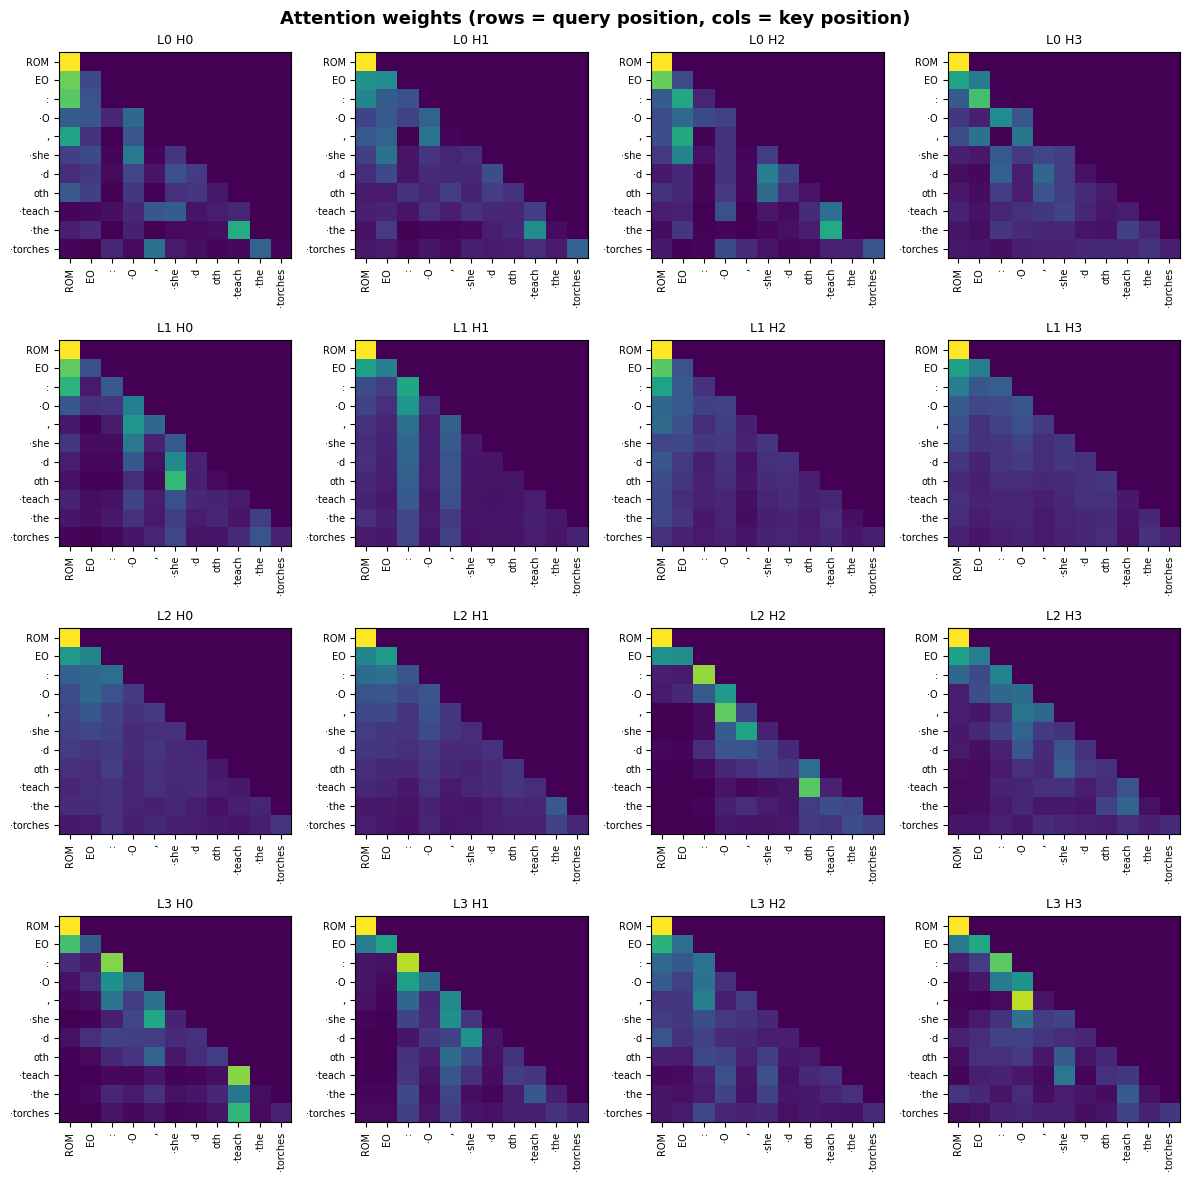

In [31]:
# Pick a recognisable Shakespearean snippet
prompt = "ROMEO: O, she doth teach the torches"
idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
attns = forward_with_attn(model, idx)

n_layers = len(attns)
n_heads = attns[0].shape[1]
T = idx.shape[1]
# Each tick label is the sub-word piece for that position
tokens = [tok.decode([i]).replace(" ", "·") for i in idx[0].tolist()]
print(f"layers: {n_layers}    heads: {n_heads}    sequence length: {T} sub-word tokens")
print(f"tokens: {tokens}")

fig, axes = plt.subplots(n_layers, n_heads, figsize=(3 * n_heads, 3 * n_layers))
for L in range(n_layers):
    for H in range(n_heads):
        ax = axes[L, H] if n_layers > 1 else axes[H]
        a = attns[L][0, H].cpu().numpy()
        ax.imshow(a, cmap="viridis", aspect="auto", vmin=0, vmax=a.max())
        ax.set_xticks(range(T)); ax.set_xticklabels(tokens, fontsize=7, rotation=90)
        ax.set_yticks(range(T)); ax.set_yticklabels(tokens, fontsize=7)
        ax.set_title(f"L{L} H{H}", fontsize=9)
fig.suptitle("Attention weights (rows = query position, cols = key position)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


> **Question 5.1** — Look across the grid of attention heatmaps.
>
> (a) Find one head that mostly attends to the **immediately previous token** (a strong sub-diagonal). What might this head be doing?
>
> (b) Find one head whose attention is much more **diffuse** or **non-local**. In which layer do diffuse patterns tend to appear — early or late?
>
> (c) Why are *all* heatmaps lower-triangular?


- **(a) Cabeza de atención al token anterior (subdiagonal marcada).** Una cabeza que asigna su peso a la posición $n-1$ para cada consulta $n$ está retransmitiendo información del **token inmediatamente anterior**. Estas cabezas capturan el orden local (una estructura similar a los bigramas) y constituyen el componente clásico de las *induction heads*, que permiten la copia en contexto (por ejemplo, `ROM` → `EO`).
- **(b) Cabeza difusa o no local.** Una cabeza cuyas filas distribuyen el peso entre muchas posiciones anteriores está **agregando contexto más amplio** en lugar de centrarse en un único vecino. Estos patrones difusos y de mayor alcance suelen aparecer en las **capas posteriores**; las capas iniciales suelen ser locales y posicionales, mientras que la atención se vuelve más abstracta y semántica a medida que aumenta la profundidad.
- **(c) Por qué todos los mapas de calor son triangulares inferiores.** Debido a la **máscara causal**: la posición $n$ solo puede atender a posiciones $\le n$. Las claves futuras ($j>i$) se fijan en $-\infty$ antes de aplicar la softmax y reciben exactamente peso cero, por lo que todo el triángulo superior queda en cero. Esto es lo que impone la propiedad autorregresiva de un decodificador de **“no mirar hacia adelante”**.


---

## Part 6 — Optional extras

These sections introduce two industry-standard tools you will encounter in real codebases. They are **optional** and can be done in any order. Allocate ~20–30 minutes total if you tackle both.


### Optional 6.1 — Rewrite attention with `torch.einsum`

The two `torch.matmul` calls in scaled dot-product attention are clean for 4-D tensors, but they hide what is actually a sum over a single axis. `torch.einsum` makes the indices explicit and generalizes effortlessly to higher-rank tensors (cross-attention, batched relative positions, etc.).

Recall the operation:

- Scores: $\mathbf{S}_{b,h,i,j} = \sum_d \mathbf{Q}_{b,h,i,d}\,\mathbf{K}_{b,h,j,d}$
- Output: $\mathbf{O}_{b,h,i,d} = \sum_j \mathbf{A}_{b,h,i,j}\,\mathbf{V}_{b,h,j,d}$

In einsum notation:

- `scores = einsum("bhid,bhjd->bhij", q, k)`
- `out    = einsum("bhij,bhjd->bhid", attn, v)`

Implement `scaled_dot_product_attention_einsum` and assert it matches the original to within `atol=1e-6`.


In [32]:
def scaled_dot_product_attention_einsum(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    d_h = q.size(-1)
    # scores[b,h,i,j] = sum_d q[b,h,i,d] * k[b,h,j,d]   (contract the head dim d)
    scores = torch.einsum("bhid,bhjd->bhij", q, k) / math.sqrt(d_h)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    attn = F.softmax(scores, dim=-1)
    # out[b,h,i,d] = sum_j attn[b,h,i,j] * v[b,h,j,d]   (contract the key dim j)
    out = torch.einsum("bhij,bhjd->bhid", attn, v)
    return out, attn


# --- equivalence check ---
torch.manual_seed(0)
B, H, T, Dh = 2, 4, 8, 16
q = torch.randn(B, H, T, Dh)
k = torch.randn(B, H, T, Dh)
v = torch.randn(B, H, T, Dh)
mask = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)

out_ref, attn_ref = scaled_dot_product_attention(q, k, v, mask)
out_ein, attn_ein = scaled_dot_product_attention_einsum(q, k, v, mask)

assert torch.allclose(out_ref, out_ein, atol=1e-6)
assert torch.allclose(attn_ref, attn_ein, atol=1e-6)
print("einsum version matches matmul version ✓")

einsum version matches matmul version ✓


> **Question 6.1** — Write down the einsum string for **cross-attention**, where queries come from one sequence of length $T_q$ and keys/values from another of length $T_k$. The score and output shapes should follow naturally from the indices.


Supongamos que las consultas (*queries*) provienen de una secuencia de longitud $T_q$ y las claves/valores (*keys/values*) de una secuencia de longitud $T_k$ (con dimensión de cabeza $D_h$). Las cadenas de `einsum` son **idénticas a las de la autoatención**; lo único que cambia es el rango de longitudes sobre el que varían los índices:

```python
scores = einsum("bhid,bhjd->bhij", q, k)    # i en [0,T_q), j en [0,T_k)  ->  (B, H, T_q, T_k)
out    = einsum("bhij,bhjd->bhid", attn, v) #                              ->  (B, H, T_q, D_h)
```

El índice de contracción `d` (sobre $D_h$) construye las puntuaciones; el índice de contracción `j` (sobre $T_k$) combina las claves/valores en un único vector para cada consulta. La salida tiene una fila por cada posición de **consulta**, por lo que su longitud es $T_q$.

Una máscara, si existe, tendría forma $(T_q, T_k)$. Esto es exactamente la atención cruzada (*cross-attention*) codificador–decodificador utilizada en los modelos *seq2seq* y en el decodificador del Transformer original.


### Optional 6.2 — Refactor the trainer into PyTorch Lightning

PyTorch Lightning is a thin wrapper over PyTorch that separates *what the model does* (`training_step`) from *how it is trained* (device placement, gradient accumulation, mixed precision, distributed training, checkpointing, logging, …). The model and data are unchanged; we re-package the loop into a `LightningModule` and let `pl.Trainer` run it.

Read the [Lightning quickstart](https://lightning.ai/docs/pytorch/stable/starter/introduction.html) once before continuing. The two methods we will use are:

- `training_step(self, batch, batch_idx)` — called once per batch with autograd enabled. Return the loss; Lightning handles `zero_grad`/`backward`/`step` for you.
- `configure_optimizers(self)` — return the optimizer (and optionally schedulers).

Run with `pl.Trainer(max_epochs=1, accelerator='auto', devices=1)`. Because Tiny Shakespeare is small and we use iteration-based training, `max_epochs=1` with a limited number of batches is plenty.


In [33]:
try:
    import pytorch_lightning as pl
except ImportError:
    %pip install -q pytorch_lightning
    import pytorch_lightning as pl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 75.7 MB/s eta 0:00:00


In [34]:
class LitMiniGPT(pl.LightningModule):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 128,
        n_heads: int = 4,
        n_layers: int = 4,
        block_size: int = 128,
        learning_rate: float = 3e-4,
    ) -> None:
        super().__init__()
        self.save_hyperparameters()
        self.model = MiniGPT(vocab_size, d_model, n_heads, n_layers, block_size)
        self.learning_rate = learning_rate

    def training_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        x, y = batch
        _, loss = self.model(x, targets=y)               # MiniGPT returns (logits, loss)
        self.log("train_loss", loss, prog_bar=True)
        return loss                                       # Lightning does backward/step for us

    def validation_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        x, y = batch
        _, loss = self.model(x, targets=y)
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self) -> torch.optim.Optimizer:
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)


lit_model = LitMiniGPT(vocab_size=vocab_size, block_size=BLOCK_SIZE)
trainer = pl.Trainer(
    max_epochs=1,
    accelerator="auto",
    devices=1,
    limit_train_batches=500,
    limit_val_batches=20,
    log_every_n_steps=50,
)
trainer.fit(lit_model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ MiniGPT │  7.2 M │ train │     0 │
└───┴───────┴─────────┴────────┴───────┴───────┘

Trainable params: 7.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.2 M                                                                                                
Total estimated model params size (MB): 28.970                                                                     
Modules in train mode: 59                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


> **Question 6.2** — Compare the Lightning code to the plain training loop from Exercise 4.1. What is automated by `pl.Trainer` that you had to write by hand? Name at least three concrete things.


`pl.Trainer` automatiza gran parte del código repetitivo (*boilerplate*) que escribimos manualmente en el Ejercicio 4.1. Al menos tres aspectos concretos son:

1. **El paso de optimización.** `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()` se ejecutan automáticamente a partir de la pérdida devuelta por `training_step`; nunca necesitamos llamarlos explícitamente.
2. **La asignación al dispositivo.** Con `accelerator="auto"`, Lightning mueve el modelo y cada lote (*batch*) a GPU/MPS/CPU automáticamente; no es necesario usar `.to(device)` manualmente sobre `model`, `xb` o `yb`.
3. **El propio bucle de entrenamiento y los modos entrenamiento/evaluación.** La iteración sobre épocas y lotes, el cambio entre `model.train()` y `model.eval()`, y el uso de `torch.no_grad()` durante la validación son gestionados por el framework.

Además de eso, también proporciona la barra de progreso y el **registro de métricas** (`self.log`), la creación de **checkpoints**, y acceso mediante una sola opción a **precisión mixta, acumulación de gradientes y entrenamiento distribuido o en múltiples GPU**, cada uno de los cuales requeriría una cantidad considerable de código adicional en un bucle de entrenamiento implementado manualmente.

---

## Done!

You just built and trained a transformer from scratch — the same architectural skeleton (with vastly more parameters and data) powers GPT-4, Claude, Gemini, LLaMA, and essentially every modern foundation model.

If you want to go further:

- Increase `d_model`, `n_layers`, and `block_size` and train longer — the model gets noticeably better at Shakespeare.
- Swap the learned positional embedding for a sinusoidal one (lecture §3.3) and compare.
- Replace the Tiny Shakespeare corpus with your own text (a code file, a book, song lyrics) and retrain — the architecture does not change at all.
- Re-implement *cross-attention* and build an encoder–decoder for a tiny seq2seq task (e.g. reversing strings).

See you in lecture 9 — **generative models**.
